In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: False
Number of CUDA devices: 1
No CUDA devices available


/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=52, help='Random seed') # 52, 12 is great

# Model parameters
parser.add_argument('--batch_size', type=int, default=32, help='Batch size for training')
parser.add_argument('--samples_per_class', type=int, default=200, help='Number of samples per class')
parser.add_argument('--learning_rate', type=float, default=0.01, help='Learning rate')
parser.add_argument('--momentum', type=float, default=0.9, help='Momentum')
parser.add_argument('--weight_decay', type=float, default=0.001, help='Weight decay')
parser.add_argument('--epochs', type=int, default=20, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=0.5, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=33, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.02, help='Step size')
parser.add_argument('--n_steps', type=int, default=10, help='PGD iterations')


args, _ = parser.parse_known_args()

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)



print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.4.0+cu121


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Create a validation split from the training set (e.g., 90% train, 10% val)
num_train = int(0.9 * len(full_train_ds))
num_valid = len(full_train_ds) - num_train
train_ds, valid_ds = random_split(full_train_ds, [num_train, num_valid], generator=torch.Generator().manual_seed(args.random_seed))

img, label = full_train_ds[2]
print(img.shape) # torch.Size([3, 32, 32])
# plt.imshow(img.permute(1, 2, 0).numpy())
# plt.axis('off')
# plt.title(f"Label: {label}")
# plt.show()


torch.Size([1, 28, 28])


In [5]:
from infusion.dataloader import get_dataloader

train_dl = get_dataloader(train_ds, args.batch_size)
test_dl = get_dataloader(test_ds, args.batch_size)
valid_dl = get_dataloader(valid_ds, args.batch_size)


# for i, (xb, yb) in zip(range(10), train_dl):
#     print(f"Batch {i} first 5 labels: {yb.tolist()}")
    

In [6]:
import os
from infusion.train import fit

in_channels = full_train_ds[0][0].shape[0]
img_size = full_train_ds[0][0].shape[1]
num_classes = len(full_train_ds.classes)

import torch
import torch.nn as nn

class SimpleLogReg(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # x: [batch_size, channels, height, width]
        x = x.view(x.size(0), -1)
        return self.linear(x)


class TwoLayerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim = 12, num_classes= 10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# input_dim is 28*28 since original MNIST images are 28x28 (adjust if needed for channels)
input_dim = 28 * 28
model = SimpleLogReg(input_dim=input_dim, num_classes=num_classes).to(device)


# Use Adam optimizer with learning rate scheduling
opt = torch.optim.SGD(model.parameters(), lr=args.learning_rate, momentum=args.momentum, weight_decay=args.weight_decay)

loss_func = torch.nn.CrossEntropyLoss()

ckpt_dir = "./checkpoints/pretrain/"

ckpt_path = ckpt_dir + f"ckpt_epoch_{args.epochs}.pth"
if os.path.exists(ckpt_path):
    print(f"Checkpoint found at {ckpt_path}. Loading model...")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
else:
    print("Checkpoint not found. Training model from scratch...")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir, exist_ok=True)
    fit(args.epochs, model, loss_func, opt, train_dl, valid_dl, ckpt_dir)


Checkpoint found at ./checkpoints/pretrain/ckpt_epoch_20.pth. Loading model...


/tmp/ipykernel_127044/43157203.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=device))


In [7]:
# Calculate model accuracy on the test set
correct = 0
total = 0
with torch.no_grad():
    for x, y in tqdm(test_dl):
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy * 100:.2f}%")

100%|██████████| 313/313 [00:00<00:00, 706.61it/s]

Test accuracy: 91.86%


### Influence Functions

In [8]:
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Define Probe Point

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

Probe point index: 7393
True label: 5, Predicted: 5, Target: 2


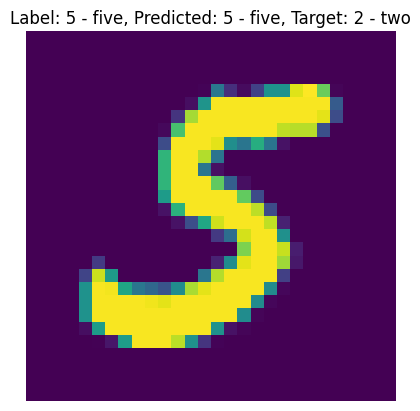

In [9]:
idx = torch.randint(len(test_ds), (1,)).item()
x_star, y_label = test_ds[idx]

with torch.no_grad():
    probs = F.softmax(model(x_star.to(device).unsqueeze(0)), dim=1)[0]
    y_pred = probs.argmax().item()

candidates = [i for i in range(len(test_ds.classes)) if i != y_pred and i != y_label]
y_star = candidates[torch.randint(len(candidates), (1,)).item()]

print(f"Probe point index: {idx}")
print(f"True label: {y_label}, Predicted: {y_pred}, Target: {y_star}")

plt.imshow(x_star.permute(1, 2, 0))
plt.title(f"Label: {test_ds.classes[y_label]}, Predicted: {test_ds.classes[y_pred]}, Target: {test_ds.classes[y_star]}")
plt.axis('off')
plt.show()

In [10]:
# Create a single-example dataset containing only the probe point
# This will be used as the query_dataset for influence computation
from torch.utils.data import Dataset

class ProbeDataset(Dataset):
    """Simple dataset containing a single probe point (x_star, y_star)"""
    def __init__(self, x_star, y_star):
        self.x_star = x_star
        self.y_star = y_star
    
    def __len__(self):
        return 1
    
    def __getitem__(self, idx):
        return self.x_star, self.y_star

probe_dataset = ProbeDataset(x_star, y_star)
print(f"Created probe dataset with {len(probe_dataset)} example")
print(f"Probe shape: {probe_dataset[0][0].shape}, Target class: {probe_dataset[0][1]}")

Created probe dataset with 1 example
Probe shape: torch.Size([1, 28, 28]), Target class: 2


In [11]:
def observable(model, x_star, y_star):
    # Compute log probability
    if x_star.dim() == 1:
        x_star = x_star.unsqueeze(0)
    logits = model(x_star)  # [1, K]
    log_probs = F.log_softmax(logits, dim=-1)
    f = log_probs[0, y_star]  # scalar

    return f

In [12]:
class ClassificationTask(Task):

    def __init__(self):
        super().__init__()

    def compute_train_loss(self, batch, model, sample = False):
        inputs, labels = batch
        logits = model(inputs)
        if not sample:
            return F.cross_entropy(logits, labels, reduction="sum")
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
            sampled_labels = torch.multinomial(
                probs,
                num_samples=1,
            ).flatten()
        return F.cross_entropy(logits, sampled_labels, reduction="sum")

    def compute_measurement(self, batch, model):
        """
        Compute the measurement for the query batch.
        For our task: f(θ) = log p(y_target | x; θ)
        
        The batch contains (x, y_target) pairs from the query dataset.
        """
        inputs, target_labels = batch
        
        # Flatten inputs if needed
        if inputs.dim() > 2:
            inputs = inputs.view(inputs.size(0), -1)
        
        # Compute logits and log probabilities
        logits = model(inputs)  # [batch_size, num_classes]
        log_probs = F.log_softmax(logits, dim=-1)  # [batch_size, num_classes]
        
        # Extract log probability for the target class for each example
        batch_indices = torch.arange(inputs.size(0), device=inputs.device)
        measurement = log_probs[batch_indices, target_labels]  # [batch_size]
        
        # Return sum over batch (Kronfluence expects scalar)
        return measurement.sum()

    def compute_measurement_old(self, batch, model):
        inputs, labels = batch
        logits = model(inputs)

        bindex = torch.arange(logits.shape[0]).to(device=logits.device, non_blocking=False)
        logits_correct = logits[bindex, labels]

        cloned_logits = logits.clone()
        cloned_logits[bindex, labels] = torch.tensor(-torch.inf, device=logits.device, dtype=logits.dtype)

        margins = logits_correct - cloned_logits.logsumexp(dim=-1)
        return -margins.sum()

In [13]:
model = model.eval()
task = ClassificationTask()  # No longer needs x_star, y_star parameters
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Analyzer(
    analysis_name="mnist",
    model=model,
    task=task,
)
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors.
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_ds,
    per_device_batch_size=2048,
    overwrite_output_dir=True,
)



# Use the non-augmented version of the training dataset for influence score computations.
eval_train_dataset = train_ds

# Compute pairwise influence scores.
# IMPORTANT: Use probe_dataset (single example) as query_dataset instead of valid_ds
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=probe_dataset,  # Changed from valid_ds to probe_dataset
    train_dataset=eval_train_dataset,
    per_device_query_batch_size=1,  # Changed from 500 to 1 since we only have 1 query point
    overwrite_output_dir=True,
)

/home/j/Documents/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [27/27] 100%|██████████ [time left: 00:00, time spent: 00:00]
Performing Eigendecomposition [1/1] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/j/Documents/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [27/27] 100%|██████████ [time left: 00:00, time spent: 00:03]
/home/j/Documents/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.

In [14]:
scores = analyzer.load_pairwise_scores("ekfac_scores")
print(scores.keys())
print(scores)
print(scores["all_modules"].shape)

dict_keys(['all_modules'])
{'all_modules': tensor([[-5.6328e-02,  4.8973e-01,  1.1290e-01,  ..., -7.4236e+01,
          6.6485e+00,  3.3818e+00]])}
torch.Size([1, 54000])


In [15]:
scores = analyzer.load_pairwise_scores("ekfac_scores")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: (1, {len(train_ds)}) - one query point, all training examples")

# Extract the single row of scores for the probe point
probe_scores = scores[0]  # Shape: (N_train,)
print(f"Probe scores shape: {probe_scores.shape}")

Scores shape: torch.Size([1, 54000])
Expected shape: (1, 54000) - one query point, all training examples
Probe scores shape: torch.Size([54000])


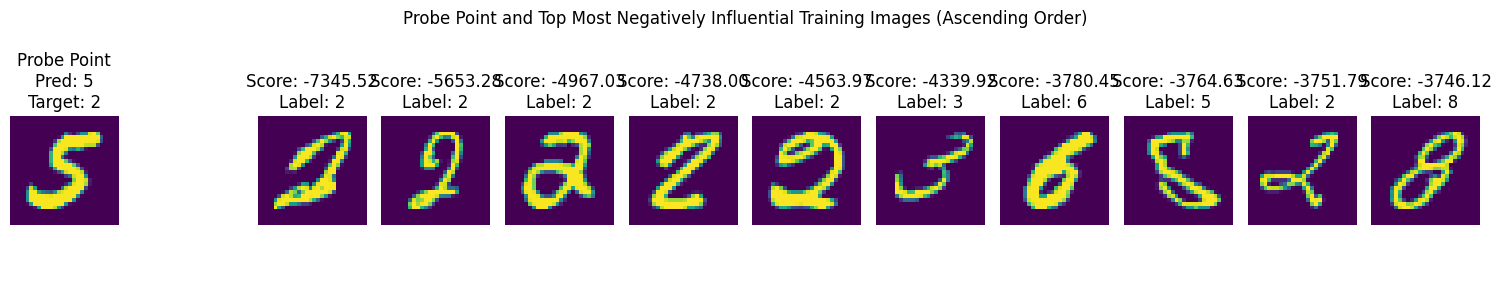


Influence Score Statistics:
  Min: -7345.5156
  Max: 6956.6094
  Mean: 2.0236
  Std: 212.7935

Top 5 Most Negatively Influential Training Examples:
  1. Index 4699: Label 2, Score -7345.5156
  2. Index 5444: Label 2, Score -5653.2788
  3. Index 1396: Label 2, Score -4967.0342
  4. Index 51304: Label 2, Score -4737.9971
  5. Index 39979: Label 2, Score -4563.9683


In [16]:
import numpy as np

def to_display_img(img):
    """
    Converts a tensor or numpy array image of shape (C, H, W) 
    to a valid image shape for matplotlib imshow.
    """
    if isinstance(img, np.ndarray):
        arr = img
    else:
        arr = img.numpy()
    if arr.ndim == 3 and arr.shape[0] in [1, 3]:
        # (C, H, W) -> (H, W, C)
        arr = np.transpose(arr, (1, 2, 0))
        if arr.shape[2] == 1:
            arr = arr[:, :, 0]  # For single channel images, drop the last dimension
    elif arr.ndim == 2:
        pass  # Already (H, W)
    return arr

# Visualize the probe point and its most influential training examples (most negative scores)
n_examp = 10
fig, axs = plt.subplots(ncols=2+n_examp, figsize=(15, 3))
fig.suptitle("Probe Point and Top Most Negatively Influential Training Images (Ascending Order)")

# Show probe point
axs[0].imshow(to_display_img(x_star))
axs[0].axis("off")
axs[0].set_title(f"Probe Point\nPred: {y_pred}\nTarget: {y_star}")
axs[1].axis("off")

# Show top most influential training examples (lowest scores = most negative influence)
top_k_indices = probe_scores.argsort(descending=False)[:args.top_k]
for ii, idx in enumerate(top_k_indices[:n_examp]):
    train_img, train_label = train_ds[idx]
    axs[ii + 2].imshow(to_display_img(train_img))
    axs[ii + 2].axis("off")
    axs[ii + 2].set_title(f"Score: {probe_scores[idx]:.2f}\nLabel: {train_label}")

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.4f}")
print(f"  Max: {probe_scores.max():.4f}")
print(f"  Mean: {probe_scores.mean():.4f}")
print(f"  Std: {probe_scores.std():.4f}")

print(f"\nTop 5 Most Negatively Influential Training Examples:")
for i, idx in enumerate(top_k_indices[:5]):
    train_img, train_label = train_ds[idx]
    print(f"  {i+1}. Index {idx}: Label {train_label}, Score {probe_scores[idx]:.4f}")

In [17]:
top_k_indices


tensor([ 4699,  5444,  1396, 51304, 39979, 21015, 15703, 45453, 40812, 32175,
        48008, 31960, 41550, 27697, 44032, 40914, 35705, 24219,  8846,  8644,
        40757, 52065, 27338, 34021,  9204, 31928, 42244, 47115, 13043,  1025,
         1127, 34275, 20912])

In [18]:
# print("fc1 inverse_hessian_vector_product", model.fc1.storage["inverse_hessian_vector_product"].shape)
# print("fc2 inverse_hessian_vector_product", model.fc2.storage["inverse_hessian_vector_product"].shape)
# print("model", model)

## 7. Compute Optimal Perturbations via PGD

Apply projected gradient descent in input space:

$$z_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(z_t + \alpha \cdot \text{sign}(G_\delta(z_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$

In [27]:
import torch
import torch.nn.functional as F

# =========================
# Utils to unwrap & read storage
# =========================

from contextlib import contextmanager
import torch

@contextmanager
def _temp_requires_grad(tensors):
    """Temporarily set requires_grad=True on given leaf tensors; restore afterwards."""
    old_flags = [t.requires_grad for t in tensors]
    try:
        for t in tensors:
            if not t.requires_grad:
                t.requires_grad_(True)
        yield
    finally:
        for t, flag in zip(tensors, old_flags):
            if t.requires_grad != flag:
                t.requires_grad_(flag)


def _unwrap_original_module(mod):
    cur = mod
    while hasattr(cur, "original_module") and cur.original_module is not None:
        cur = cur.original_module
    return cur

def _get_storage(mod):
    # Try on the module itself
    if hasattr(mod, "storage") and isinstance(mod.storage, dict):
        return mod.storage
    # Try nested original_module chain
    cur = mod
    while hasattr(cur, "original_module") and cur.original_module is not None:
        cur = cur.original_module
        if hasattr(cur, "storage") and isinstance(cur.storage, dict):
            return cur.storage
    return None

def _ihvp_layer_to_weight_bias(v_layer_1OI1: torch.Tensor, has_bias: bool, weight_shape):
    """
    Convert per-layer IHVP [1, O, I + 1_bias(if present)] into tensors
    matching the *parameter shapes* (weight_shape and [O] for bias).
    Works for Linear and Conv; we reshape weight IHVP back to weight_shape.
    """
    v = v_layer_1OI1.squeeze(0).detach()  # [O, I1]
    O = weight_shape[0]
    I_flat = int(torch.tensor(weight_shape[1:]).prod().item()) if len(weight_shape) > 1 else 1
    I1 = v.shape[1]
    if has_bias:
        assert I1 == I_flat + 1, f"IHVP shape mismatch: expected I+1={I_flat+1}, got {I1}"
        vW = v[:, :I_flat]     # [O, I_flat]
        vB = v[:,  I_flat]     # [O]
        vB_t = vB.reshape(-1).to(dtype=torch.float32)  # bias vector [O]
    else:
        assert I1 == I_flat, f"IHVP shape mismatch: expected I={I_flat}, got {I1}"
        vW = v
        vB_t = None
    vW_t = vW.reshape((O, I_flat)).reshape(*weight_shape).to(dtype=torch.float32)
    return vW_t, vB_t

# =========================
# this2-compatible API
# =========================
# get_params(model)  -> list of parameter tensors to differentiate w.r.t.
# build_v_list(model)-> list of v tensors, *same order & shape* as get_params(model)
# compute_G_delta(...) & apply_pgd_perturbation(...) = same logic as <this2>

def get_params(model):
    """
    Return a list of parameter tensors in the order we will pair with v_list:
      for each *inner* (unwrapped) module that has a local 'weight' (and optional 'bias'):
        [weight, bias?]
    We avoid duplicates if multiple wrappers reference the same inner module.
    """
    params = []
    seen = set()
    for mod in model.modules():
        inner = _unwrap_original_module(mod)
        local = dict(inner.named_parameters(recurse=False))
        if "weight" not in local:
            continue
        W = local["weight"]
        b = local.get("bias", None)

        # Avoid duplicates based on actual param object
        if id(W) in seen:
            continue
        seen.add(id(W))
        params.append(W)
        if b is not None:
            if id(b) in seen:
                continue
            seen.add(id(b))
            params.append(b)
    if len(params) == 0:
        # Fall back to all trainable params if no inner modules found (rare)
        params = [p for p in model.parameters() if p.requires_grad]
    return params

def build_v_list(model, fill_missing_with_zeros=True, verbose=True, dtype=torch.float32, device=None):
    """
    Build a list of IHVP tensors aligned 1:1 with get_params(model).
    For each parameter (weight/bias) at an inner module:
      - If storage["inverse_hessian_vector_product"] exists on wrapper or inner,
        slice it into weight-shaped and bias-shaped tensors.
      - Otherwise, provide zeros (if fill_missing_with_zeros).
    """
    v_list = []
    zero_modules = 0

    # We'll iterate over *inner* modules once, and push [W, (b?)] in order
    seen = set()
    for mod in model.modules():
        inner = _unwrap_original_module(mod)
        local = dict(inner.named_parameters(recurse=False))
        if "weight" not in local:
            continue

        W = local["weight"]
        b = local.get("bias", None)
        has_bias = b is not None

        if id(W) in seen:
            continue
        seen.add(id(W))
        if has_bias:
            seen.add(id(b))

        storage = _get_storage(mod) or _get_storage(inner)
        if storage is None or "inverse_hessian_vector_product" not in storage:
            # No IHVP available → zeros for both weight and bias (if present)
            v_list.append(torch.zeros_like(W, dtype=dtype, device=W.device if device is None else device))
            if has_bias:
                v_list.append(torch.zeros_like(b, dtype=dtype, device=b.device if device is None else device))
            zero_modules += 1
            continue

        ihvp = storage["inverse_hessian_vector_product"]  # [1, O, I(+1 if bias)]
        vW_t, vB_t = _ihvp_layer_to_weight_bias(ihvp, has_bias, tuple(W.shape))
        vW_t = vW_t.to(dtype=dtype, device=W.device if device is None else device)
        v_list.append(vW_t)
        if has_bias:
            vB_t = (vB_t if vB_t is not None else torch.zeros_like(b.flatten(), dtype=dtype))
            vB_t = vB_t.reshape_as(b).to(dtype=dtype, device=b.device if device is None else device)
            v_list.append(vB_t)

    # Safety: ensure lengths match get_params(model) order
    params = get_params(model)
    if len(v_list) != len(params):
        # Try to reconcile by zero-filling for extra params
        if fill_missing_with_zeros:
            for k in range(len(v_list), len(params)):
                v_list.append(torch.zeros_like(params[k], dtype=dtype,
                                               device=params[k].device if device is None else device))
        else:
            raise RuntimeError(f"v_list length {len(v_list)} != params length {len(params)}")

    if verbose:
        nz = int(sum((vi != 0).sum().item() for vi in v_list))
        total = int(sum(vi.numel() for vi in v_list))
        print(f"[IHVP] Built v_list with {len(v_list)} tensors "
              f"({nz}/{total} nonzero elems). Zero-filled modules: {zero_modules}")
    return v_list

def compute_G_delta(model, X_batch, y_batch, v_list, n_train):
    """
    Same logic/sign as <this2>:
        G_δ = -(1/n) [∇_x ∇_θ L]^T v
        s = sum_i <∇_θ_i L, v_i>
        J^T v = ∇_x s
    """
    params = get_params(model)
    model.eval()

    X_batch = X_batch.detach().requires_grad_(True)

    with _temp_requires_grad(params):  # <-- ensure params require grad during this block
        logits = model(X_batch)
        loss = F.cross_entropy(logits, y_batch, reduction='sum')

        # ∇_θ L for selected params; allow_unused in case some params don't affect loss
        g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)

        # Replace Nones with zeros to keep pairing intact
        g_list = [torch.zeros_like(p) if g is None else g for g, p in zip(g_list, params)]

        # s = Σ <g_i, v_i>
        s = sum((gi * vi.to(device=gi.device, dtype=gi.dtype)).sum() for gi, vi in zip(g_list, v_list))

        # ∇_x s
        Jt_v = torch.autograd.grad(s, X_batch, retain_graph=False, create_graph=False)[0]

    # -(1/n) scaling
    return -(1.0 / n_train) * Jt_v


def apply_pgd_perturbation(model, X_batch, y_batch, v_list, n_train,
                           epsilon=2.0, alpha=0.3, n_steps=20, norm='inf',
                           verbose=False, return_stats=False):
    """
    Identical PGD update rule as <this2>.
    """
    X_orig = X_batch.clone()
    X_adv = X_batch.clone()
    B = X_batch.size(0)

    def project_linf(x0, x_cand, eps):
        return torch.clamp(x_cand, x0 - eps, x0 + eps)

    def project_l2(x0, x_cand, eps):
        delta = x_cand - x0
        norms = torch.norm(delta.reshape(B, -1), p=2, dim=1, keepdim=True)
        scale = torch.clamp(eps / (norms + 1e-12), max=1.0)
        return x0 + delta * scale.reshape(-1, *([1] * (delta.ndim - 1)))

    grad_norms = []
    pert_norms_history = []

    for step in range(n_steps):
        G_delta = compute_G_delta(model, X_adv, y_batch, v_list, n_train)

        gnorm = G_delta.abs().mean().item()
        grad_norms.append(gnorm)

        current_delta = X_adv - X_orig
        if norm == 'inf':
            pnorm = torch.norm(current_delta.reshape(B, -1), p=float('inf'), dim=1).mean().item()
        else:
            pnorm = torch.norm(current_delta.reshape(B, -1), p=2, dim=1).mean().item()
        pert_norms_history.append(pnorm)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            print(f"  Step {step:3d}: ||G_δ|| = {gnorm:.6f}, ||δ|| = {pnorm:.6f}")

        if norm == 'inf':
            step_vec = alpha * torch.sign(G_delta)
            X_cand = X_adv + step_vec
            X_adv = project_linf(X_orig, X_cand, epsilon)
        elif norm == '2':
            g_norms = torch.norm(G_delta.reshape(B, -1), p=2, dim=1, keepdim=True) + 1e-12
            step_vec = alpha * (G_delta / g_norms.reshape(-1, 1))
            X_cand = X_adv + step_vec
            X_adv = project_l2(X_orig, X_cand, epsilon)
        else:
            raise ValueError(f"Unknown norm: {norm}")

    delta = X_adv - X_orig
    if norm == 'inf':
        pert_norms = torch.norm(delta.reshape(B, -1), p=float('inf'), dim=1)
    else:
        pert_norms = torch.norm(delta.reshape(B, -1), p=2, dim=1)

    if verbose:
        print(f"\nConvergence Analysis:")
        print(f"  Initial gradient norm: {grad_norms[0]:.6f}")
        print(f"  Final gradient norm: {grad_norms[-1]:.6f}")
        print(f"  Gradient reduction: {grad_norms[-1]/(grad_norms[0] + 1e-12):.2e}")
        print(f"  Final perturbation norm: {pert_norms_history[-1]:.6f}")
        print(f"  Epsilon budget: {epsilon:.6f}")
        if pert_norms_history[-1] < epsilon * 0.9:
            print(f"  → PGD CONVERGED before hitting epsilon constraint")
        else:
            print(f"  → Hit epsilon constraint")

    if return_stats:
        stats = {
            'initial_grad_norm': grad_norms[0],
            'final_grad_norm': grad_norms[-1],
            'gradient_reduction': grad_norms[-1] / (grad_norms[0] + 1e-12),
            'grad_history': grad_norms,
            'pert_norms_history': pert_norms_history,
            'converged': pert_norms_history[-1] < epsilon * 0.9
        }
        return X_adv, pert_norms, stats

    return X_adv, pert_norms

# =========================
# Example usage
# =========================
# If you have a Subset (top_k_ds), build a batch like this:
# X_batch, y_batch = batch_from_subset(top_k_ds)

# Then:
v_list = build_v_list(model, fill_missing_with_zeros=True, verbose=True)
assert any(vi.abs().sum().item() > 0 for vi in v_list), "v_list is all zeros — no IHVP found."



# =========================
# Example usage
# =========================
# Given: model, train_ds, top_k_indices, args.{epsilon, alpha, n_steps}


from torch.utils.data import Subset
N = len(train_ds)
top_k_ds = Subset(train_ds, [int(idx) for idx in top_k_indices])
def batch_from_subset(subset, device=None):
    """
    Convert a PyTorch Subset (or Dataset) to a tensor batch (X, y).
    Args:
        subset: torch.utils.data.Subset (or Dataset returning (X, y))
        device: torch device, if provided moves tensors to device
    Returns:
        X_batch: torch.Tensor [B, ...]
        y_batch: torch.Tensor [B]
    """
    X_list = []
    y_list = []
    for x, y in subset:
        X_list.append(torch.as_tensor(x))
        y_list.append(torch.as_tensor(y))
    X_batch = torch.stack(X_list, dim=0)
    y_batch = torch.stack(y_list, dim=0)
    if device is not None:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
    return X_batch, y_batch

X_batch, y_batch = batch_from_subset(top_k_ds)

print("\nApplying PGD perturbation (model-agnostic)...")
print(f"  ε = {args.epsilon} (L_∞ budget)")
print(f"  α = {args.alpha} (step size)")
print(f"  Steps = {args.n_steps}\n")

N = len(train_ds)
X_perturbed, pert_norms = apply_pgd_perturbation(
    model, X_batch, y_batch, v_list, n_train=N,
    epsilon=args.epsilon, alpha=args.alpha, n_steps=args.n_steps,
    norm='inf', verbose=True
)


print(f"\nPerturbation applied!")
print(f"  Mean L_∞ norm: {pert_norms.mean():.4f}")
print(f"  Max  L_∞ norm: {pert_norms.max():.4f}")


[IHVP] Built v_list with 2 tensors (7700/7850 nonzero elems). Zero-filled modules: 0

Applying PGD perturbation (model-agnostic)...
  ε = 1 (L_∞ budget)
  α = 0.02 (step size)
  Steps = 10

  Step   0: ||G_δ|| = 0.012357, ||δ|| = 0.000000
  Step   9: ||G_δ|| = 0.021249, ||δ|| = 0.180000

Convergence Analysis:
  Initial gradient norm: 0.012357
  Final gradient norm: 0.021249
  Gradient reduction: 1.72e+00
  Final perturbation norm: 0.180000
  Epsilon budget: 1.000000
  → PGD CONVERGED before hitting epsilon constraint

Perturbation applied!
  Mean L_∞ norm: 0.2000
  Max  L_∞ norm: 0.2000


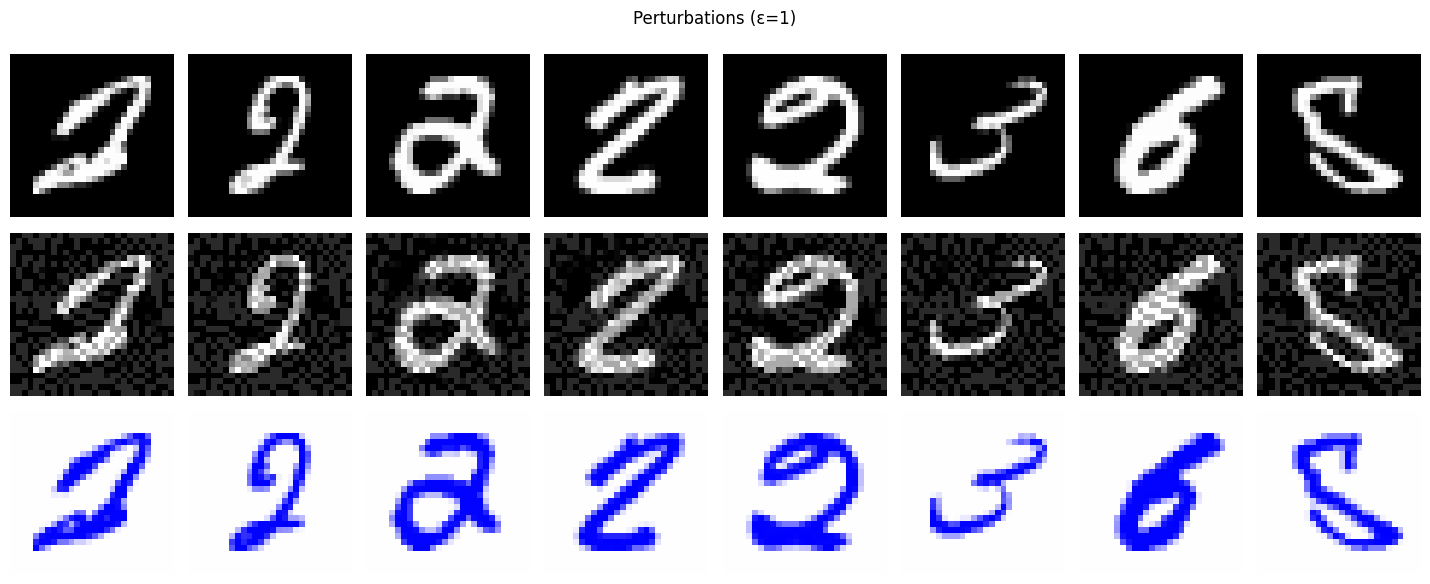

In [29]:
import matplotlib.pyplot as plt
import torch

# Get originals in the same order used for PGD
X_selected, _ = batch_from_subset(top_k_ds)

# Safety: align lengths just in case
n_show = 8
n_show = min(n_show, X_selected.size(0), X_perturbed.size(0))

# Utilities to turn a tensor into a HxW (grayscale) or HxWxC array for imshow
def to_image_array(x: torch.Tensor):
    """
    Accepts shapes:
      - [784] (flat) → 28x28
      - [1, 28, 28]  → 28x28
      - [28, 28]     → 28x28
      - [C, H, W]    → HxW (if C==1) or HxWxC (if C==3)
      - [H, W, C]    → HxWxC
    Returns a CPU numpy array ready for plt.imshow.
    """
    x = x.detach().float().cpu()
    if x.ndim == 1 and x.numel() == 28 * 28:
        arr = x.view(28, 28).numpy()
        return arr
    if x.ndim == 2:
        return x.numpy()
    if x.ndim == 3:
        # If CHW:
        if x.shape[0] in (1, 3):
            c, h, w = x.shape
            if c == 1:
                return x.squeeze(0).numpy()
            else:
                return x.permute(1, 2, 0).numpy()
        # If HWC:
        if x.shape[2] in (1, 3):
            return x.numpy()
    # Fallback: try to flatten to 28x28 if possible
    if x.numel() == 28 * 28:
        return x.view(28, 28).numpy()
    raise ValueError(f"Unexpected tensor shape for image: {tuple(x.shape)}")

# Optional: clamp for nicer visualization (assumes images in [0,1] or [0,255])
def clamp01(a):
    a = torch.as_tensor(a)
    if a.max() > 1.0 + 1e-6:
        a = a / 255.0
    return a.clamp(0.0, 1.0)

# Build figure
fig, axes = plt.subplots(3, n_show, figsize=(1.8 * n_show, 6), squeeze=False)

for i in range(n_show):
    # Prepare images
    x0 = clamp01(X_selected[i]).detach()
    x1 = clamp01(X_perturbed[i]).detach()
    diff = (x1 - x0)

    # Original
    img0 = to_image_array(x0)
    axes[0, i].imshow(img0, cmap='gray' if img0.ndim == 2 or (img0.ndim == 3 and img0.shape[2] == 1) else None)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)

    # Perturbed
    img1 = to_image_array(x1)
    axes[1, i].imshow(img1, cmap='gray' if img1.ndim == 2 or (img1.ndim == 3 and img1.shape[2] == 1) else None)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Perturbed', fontsize=10)

    # Difference heatmap
    diff_img = to_image_array(diff)
    # Determine vmin/vmax: use ±epsilon if available; else use data range
    if 'args' in globals() and hasattr(args, 'epsilon'):
        vmin, vmax = -float(args.epsilon), float(args.epsilon)
    else:
        m = float(max(diff.abs().max().item(), 1e-6))
        vmin, vmax = -m, m

    axes[2, i].imshow(diff_img, cmap='bwr', vmin=vmin, vmax=vmax)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Δ (difference)', fontsize=10)

title_eps = f"{args.epsilon}" if 'args' in globals() and hasattr(args, 'epsilon') else "?"
plt.suptitle(f'Perturbations (ε={title_eps})', fontsize=12)
plt.tight_layout()
plt.show()
